# Student Performance Predictor

### Machine Learning Open-Ended Lab

**Project Name:** Student Performance Predictor  
**Student Name:** Syeda Aaisha Fatima  
**Roll No:** _____24f-ai-055_____________  
**Program:** BS Artificial Intelligence  
**Course:** Machine Learning  
**University:** Dawood University of Engineering and Technology  

## Objective

To develop a machine learning application that predicts student academic
performance using student-related features.

The project integrates data preprocessing, data visualization, regression,
classification, and model evaluation.

### Machine Learning Models Used

1. Linear Regression — to predict the student's final grade (G3)
2. Logistic Regression — to predict whether the student will Pass or Fail

In [32]:
# Importing the libraries that we will need for this project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix
)

In [33]:
# Uploading the ZIP file that contains our student dataset

from google.colab import files

uploaded = files.upload()

Saving student+performance.zip to student+performance (1).zip


In [34]:
# Extracting the uploaded ZIP file so we can access the dataset files
import zipfile

with zipfile.ZipFile("student+performance.zip", "r") as zip_ref:
    zip_ref.extractall("student_data")

print("ZIP extracted successfully!")

ZIP extracted successfully!


In [35]:
with zipfile.ZipFile("student_data/student.zip", "r") as zip_ref:
    zip_ref.extractall("student_data/extracted")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [36]:
# There is another ZIP file inside the main ZIP,
# so we are extracting it to get the actual CSV files
df = pd.read_csv(
    "student_data/extracted/student-mat.csv",
    sep=";"
)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [37]:
# Looking at the first five rows to understand how our data looks
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [38]:
# Checking how many students and columns are present in our dataset
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 395
Columns: 33


In [39]:
# Checking all the column names so we can decide which features to use
print(df.columns)

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')


In [74]:
# Getting some basic statistics like mean, minimum and maximum values

df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,Pass
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190,0.670886
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443,0.470487
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000,0.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000,1.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000,1.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000,1.000000


In [75]:
# Getting some basic statistics like mean, minimum and maximum values

df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,Pass
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190,0.670886
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443,0.470487
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000,0.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000,1.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000,1.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000,1.000000


In [40]:
#check missing values
print(df.isnull().sum())

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [41]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [42]:
# Selecting the features that we think can help predict the final grade

features = ["studytime", "absences", "G1", "G2"]

X = df[features]

y = df["G3"]

In [43]:
print(X.head())

   studytime  absences  G1  G2
0          2         6   5   6
1          2         4   5   5
2          2        10   7   8
3          3         2  15  14
4          2         4   6  10


In [44]:
print(y.head())

0     6
1     6
2    10
3    15
4    10
Name: G3, dtype: int64


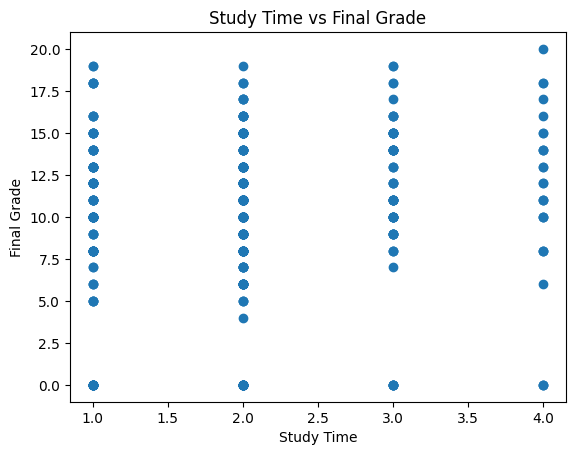

In [45]:
# Plotting study time against final grade
# This helps us see whether study time has any visible relationship with grades
plt.scatter(
    df["studytime"],
    df["G3"]
)

plt.xlabel("Study Time")
plt.ylabel("Final Grade")
plt.title("Study Time vs Final Grade")

plt.show()

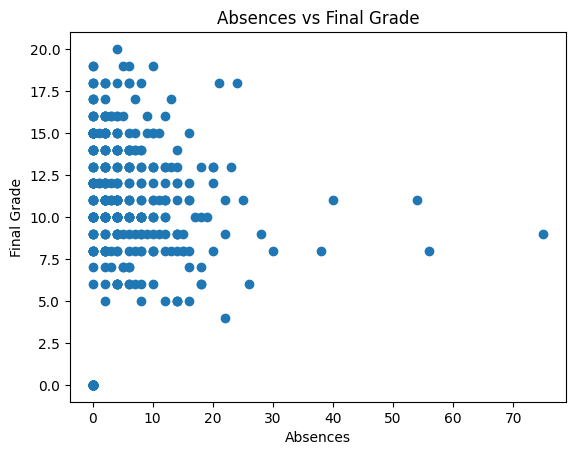

In [46]:
# Plotting absences against final grade
# We want to see whether students with more absences tend to have lower grades
plt.scatter(
    df["absences"],
    df["G3"]
)

plt.xlabel("Absences")
plt.ylabel("Final Grade")
plt.title("Absences vs Final Grade")

plt.show()

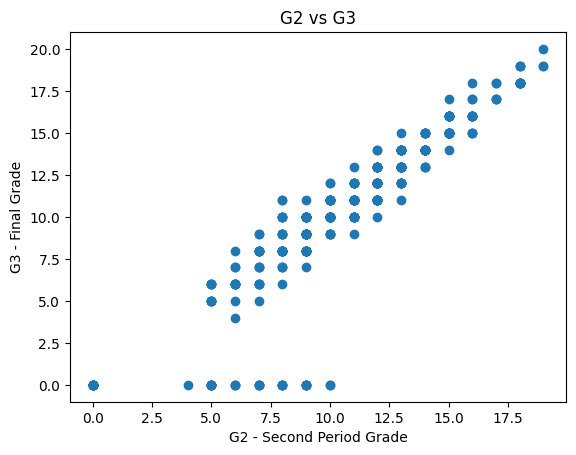

In [47]:
# Comparing the second period grade with the final grade
# G2 can give us useful information about the student's final performance
plt.scatter(
    df["G2"],
    df["G3"]
)

plt.xlabel("G2 - Second Period Grade")
plt.ylabel("G3 - Final Grade")
plt.title("G2 vs G3")

plt.show()

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [49]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (316, 4)
Testing data: (79, 4)


In [50]:
 # Scaling the features so that they are on a similar numerical scale
 scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [51]:
scaler.fit_transform(X_train)

array([[-0.05685286, -0.46440769,  0.33205033,  0.62616324],
       [-1.25455313, -0.70225668,  0.64340909,  0.89283114],
       [-0.05685286, -0.70225668, -0.91338472, -0.97384417],
       ...,
       [-0.05685286,  1.08161077, -0.60202596, -0.44050837],
       [ 1.14084741, -0.70225668,  0.64340909,  1.15949904],
       [-1.25455313, -0.22655869, -0.2906672 ,  0.62616324]])

In [52]:
scaler.fit_transform(X_train)

array([[-0.05685286, -0.46440769,  0.33205033,  0.62616324],
       [-1.25455313, -0.70225668,  0.64340909,  0.89283114],
       [-0.05685286, -0.70225668, -0.91338472, -0.97384417],
       ...,
       [-0.05685286,  1.08161077, -0.60202596, -0.44050837],
       [ 1.14084741, -0.70225668,  0.64340909,  1.15949904],
       [-1.25455313, -0.22655869, -0.2906672 ,  0.62616324]])

In [53]:
model = LinearRegression()

In [54]:
 Creating our first machine learning model
# Linear Regression will predict the student's final grade
model.fit(
    X_train_scaled,
    y_train
)

LinearRegression()

In [76]:
# Using the trained model to predict final grades for the test students
y_pred = model.predict(
    X_test_scaled
)
print(y_pred[:10])

[ 7.10303103 12.10922942  3.47955361  8.28177318  8.56270885 12.61066495
 18.81452156  6.84469902  6.98026635 12.52212142]


In [56]:
# Calculating the Mean Absolute Error
# It tells us how far the predictions are from the actual grades on average
mae = mean_absolute_error(
    y_test,
    y_pred
)

print("MAE:", mae)

MAE: 1.312574939624357


In [57]:
#claculate mean squared error to measure prediction error
mse = mean_squared_error(
    y_test,
    y_pred
)

print("MSE:", mse)

MSE: 4.178975406386837


In [58]:
# Taking the square root of MSE to get RMSE
# Lower RMSE generally means better prediction performance

rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 2.044254242110515


In [59]:
# Calculating R-squared to see how well our model explains the final grades

r2 = r2_score(
    y_test,
    y_pred
)

print("R²:", r2)

R²: 0.7961977189442984


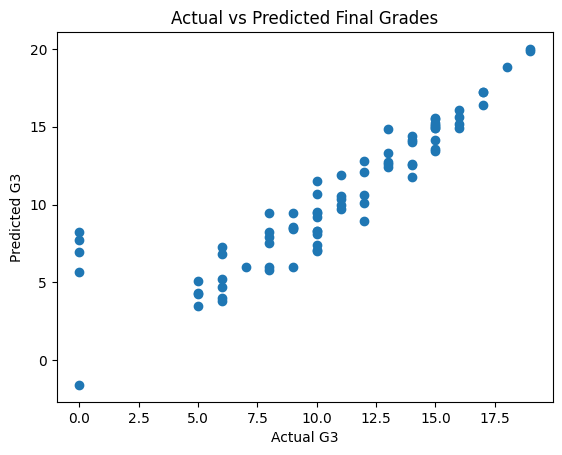

In [60]:
# Displaying all the evaluation results together

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Actual vs Predicted Final Grades")

plt.show()

In [62]:
# Create the 'Pass' column where a grade of 10 or above is a Pass (1) and below is Fail (0)
df["Pass"] = (df["G3"] >= 10).astype(int)

# Display the counts of Pass 1 and Fail 0
print(df["Pass"].value_counts())

Pass
1    265
0    130
Name: count, dtype: int64


In [63]:
X_class = df[features]

y_class = df["Pass"]

In [64]:
 #Splitting the data for the classification model
# Stratify keeps the Pass/Fail proportion similar in both sets
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

In [65]:

scaler_class = StandardScaler()

X_train_class_scaled = scaler_class.fit_transform(
    X_train_class
)

X_test_class_scaled = scaler_class.transform(
    X_test_class
)

In [66]:
logistic_model = LogisticRegression()

In [67]:
logistic_model.fit(
    X_train_class_scaled,
    y_train_class
)

LogisticRegression()

In [68]:
y_pred_class = logistic_model.predict(
    X_test_class_scaled
)

In [69]:
print(y_pred_class[:20])

[1 0 1 1 1 1 1 0 1 1 1 0 1 1 0 1 0 0 0 0]


In [70]:
accuracy = accuracy_score(
    y_test_class,
    y_pred_class
)

print("Accuracy:", accuracy)

Accuracy: 0.8860759493670886


In [71]:
recall = recall_score(
    y_test_class,
    y_pred_class
)

print("Recall:", recall)

Recall: 0.8867924528301887


In [77]:
# Precision tells us how many students predicted as Pass actually passed

precision = precision_score(
    y_test_class,
    y_pred_class
)

print("Precision:", precision)

Precision: 0.94


In [78]:
# Showing all the classification evaluation results together

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)

Logistic Regression Results
---------------------------
Accuracy : 0.8860759493670886
Precision: 0.94
Recall   : 0.8867924528301887


In [79]:
# Creating the confusion matrix to see correct and incorrect predictions

cm = confusion_matrix(
    y_test_class,
    y_pred_class
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[23  3]
 [ 6 47]]


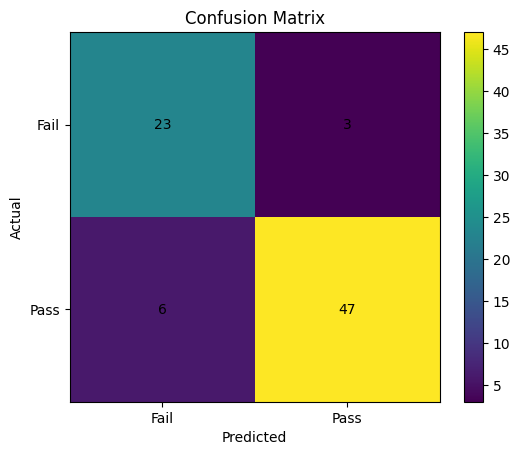

In [73]:
plt.imshow(cm)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["Fail", "Pass"]
)

plt.yticks(
    [0, 1],
    ["Fail", "Pass"]
)

plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.show()

In [80]:
# Comparing the main result of both models
# The two models have different tasks, so their metrics are also different

print("Model Comparison")
print("-----------------")

print("Linear Regression R²:", r2)

print("Logistic Regression Accuracy:", accuracy)

Model Comparison
-----------------
Linear Regression R²: 0.7961977189442984
Logistic Regression Accuracy: 0.8860759493670886


In [81]:
# Creating a sample student to see how our trained models make predictions

new_student = pd.DataFrame({
    "studytime": [3],
    "absences": [3],
    "G1": [14],
    "G2": [15]
})

print("New student information:")
display(new_student)

New student information:


,studytime,absences,G1,G2
0,3,3,14,15


In [82]:
# Scaling the new student's information using the scaler we already trained

new_student_scaled = scaler.transform(
    new_student
)

# Predicting the student's final grade

predicted_grade = model.predict(
    new_student_scaled
)

print(
    "Predicted Final Grade:",
    round(predicted_grade[0], 2)
)

Predicted Final Grade: 15.0


In [83]:
# Scaling the new student's data for the classification model

new_student_class_scaled = scaler_class.transform(
    new_student
)

# Predicting whether the student will pass or fail

predicted_class = logistic_model.predict(
    new_student_class_scaled
)

if predicted_class[0] == 1:
    result = "Pass"
else:
    result = "Fail"

print("Predicted Result:", result)

Predicted Result: Pass


In [84]:
# Showing the complete prediction for our sample student

print("================================")
print("   STUDENT PERFORMANCE RESULT")
print("================================")

print("Study Time:", new_student["studytime"].iloc[0])
print("Absences:", new_student["absences"].iloc[0])
print("G1:", new_student["G1"].iloc[0])
print("G2:", new_student["G2"].iloc[0])

print(
    "Predicted Final Grade:",
    round(predicted_grade[0], 2)
)

print("Predicted Result:", result)

print("================================")

   STUDENT PERFORMANCE RESULT
Study Time: 3
Absences: 3
G1: 14
G2: 15
Predicted Final Grade: 15.0
Predicted Result: Pass
